# Построить прогноз на 8 месяцев методом экспоненциального сглаживания

Общее описание данных

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics
Данные собирались ежемесячно с января 1994 по апрель 2003

Источник данных: http://www.choosechicago.com/.

Вариант 3 выполняют те, чья фамилия начинается с букв Л - С

Вариант 3:
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца.
Данные расположены в столбце x3 файла Chicago_hotels.csv

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

from statsmodels.tsa.api import ExponentialSmoothing

Грузим данные и берем только нужный столбец.

In [2]:
df = df = pd.read_csv('/content/data.csv', sep=';', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


In [13]:
df3 = df[['date1', 'date2', 'x3']].copy()
df3['date'] = df3['date1'].str.strip() + ' ' + df3['date2'].astype(str)
df3 = df3[['date', 'x3']]
df3['date'] = pd.to_datetime(df3['date'])
df3.set_index('date', inplace=True)

# Проверка
df3.head()

/tmp/ipykernel_6227/2264257720.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df3['date'] = pd.to_datetime(df3['date'])


,x3
date,
1994-01-01,51.9
1994-02-01,60.1
1994-03-01,65.0
1994-04-01,69.8
1994-05-01,72.4


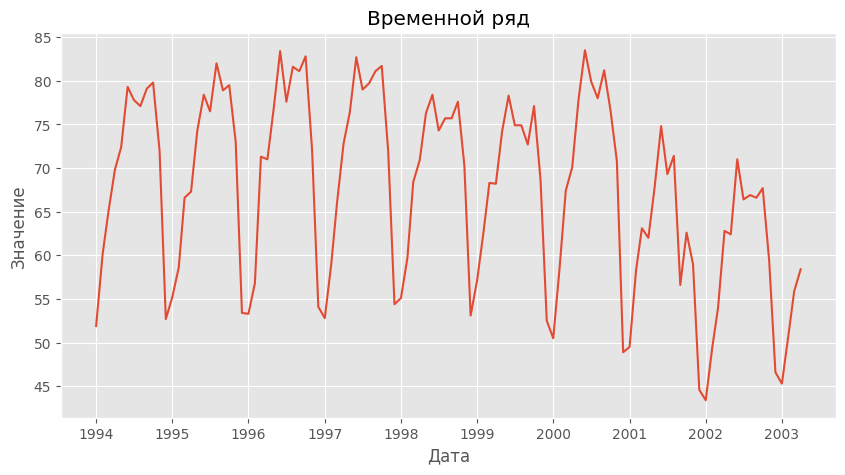

In [14]:
ts = df3['x3'].copy()

plt.figure(figsize=(10,5))
plt.plot(ts)
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.title("Временной ряд")
plt.show()

Строим модель для прогноза через экспоненциальное сглаживание. Берем аддитивный метод, период 12 (так как по месяцам), всегда trend='additive' по рекомендации Hyndman'а и trend='damped'

In [15]:
fit1 = ExponentialSmoothing(np.asarray(ts) ,seasonal_periods=12 ,trend='additive', seasonal='additive', damped_trend = True).fit()
len(ts)

112

In [19]:
fitted_ = fit1.predict(0, 121)
fitted_

array([52.33740424, 58.38917412, 66.76513061, 68.80049077, 74.48428692,
       79.32345131, 75.74585749, 78.33913266, 76.29673204, 79.3702217 ,
       72.19788655, 54.84072024, 54.04137249, 60.79425111, 66.96313065,
       69.62145792, 73.43103145, 79.73757567, 75.37026087, 77.38894074,
       78.37685447, 80.17006471, 72.35038654, 55.38559159, 54.61608112,
       60.00696871, 65.59446553, 71.43566238, 76.21044242, 82.33563994,
       79.21376703, 79.74821642, 79.24596042, 81.72319078, 74.81044814,
       56.0425326 , 55.27871202, 60.03656917, 66.76234142, 69.20906647,
       76.1102274 , 82.06545328, 78.70551972, 80.24434467, 78.46154035,
       81.34788988, 74.04355095, 55.5705075 , 55.21103481, 61.22106637,
       67.68489962, 70.85883157, 75.8711199 , 81.89669124, 76.33976756,
       76.63612999, 74.64261443, 76.68695081, 69.67827162, 52.6716387 ,
       53.15936567, 61.31925209, 69.32249029, 71.57233479, 74.77071206,
       80.26432564, 75.52007297, 76.56936894, 74.18561605, 74.87

In [24]:
fitted_series = pd.Series(
    fitted_,
    index=pd.date_range(
        start=ts.index[0],
        periods=len(fitted_),
        freq='MS'
    )
)

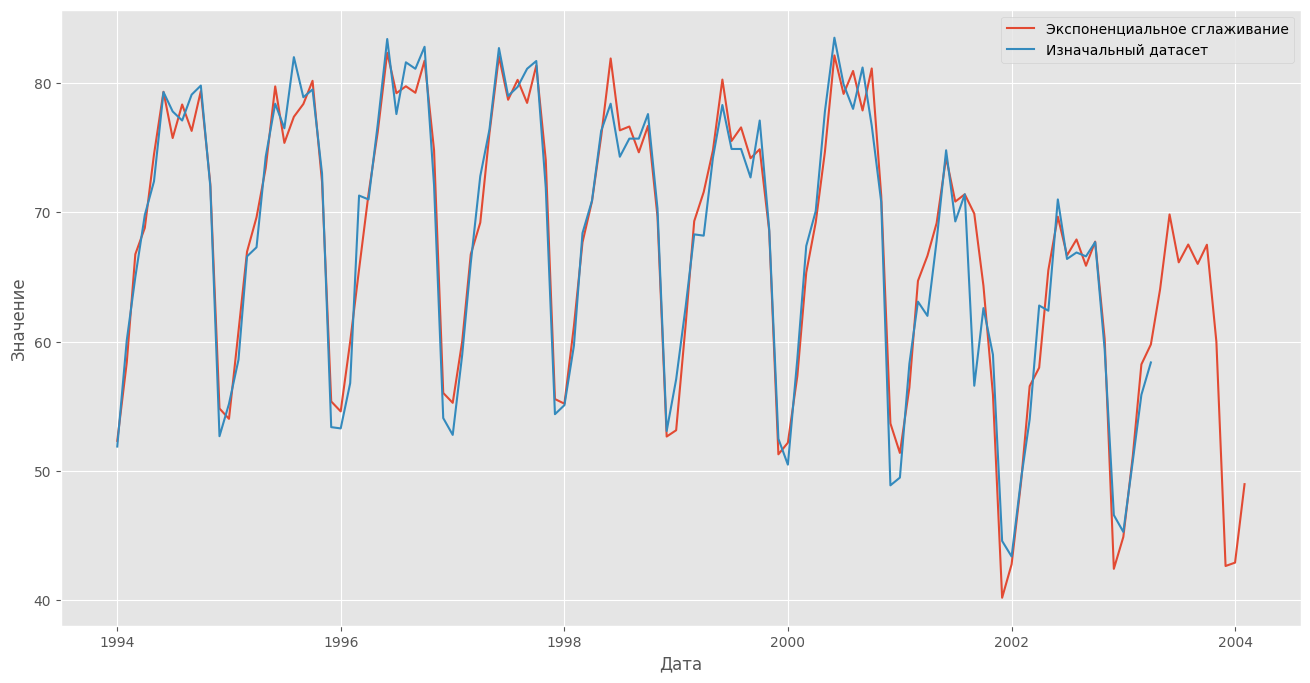

In [27]:
plt.figure(figsize=(16,8))
plt.plot(fitted_series, label='Экспоненциальное сглаживание')
plt.plot(ts, label='Изначальный датасет')
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend(loc='best')
plt.show()

Сам прогноз

In [12]:
fitted_[112:121]

array([64.04237799, 69.83849939, 66.13684376, 67.51495332, 66.01725452,
       67.49892095, 60.00432216, 42.6665627 , 42.92593212])